In [46]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve
from matplotlib.ticker import MultipleLocator


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

In [83]:
file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Data\Stückchen\Raman\Raman_Spanien\Exports\800_1100-1800_voigt.txt"

data_800 = pd.read_csv(file_path, sep='\t')

# deduct baseline + O2 line
data_800['Corrected Intensity'] = data_800['Intensity'] - data_800['Baseline'] - data_800['O2']
print(data_800.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2652 entries, 0 to 2651
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Raman shift          2652 non-null   float64
 1   Intensity            2652 non-null   float64
 2   calib. shift         2652 non-null   float64
 3   Baseline             2652 non-null   float64
 4   O2                   2652 non-null   float64
 5   G                    2652 non-null   float64
 6   D                    2652 non-null   float64
 7   D3                   2652 non-null   float64
 8   D4                   2652 non-null   float64
 9   Fit Sum              2652 non-null   float64
 10  Corrected Intensity  2652 non-null   float64
dtypes: float64(11)
memory usage: 228.0 KB
None


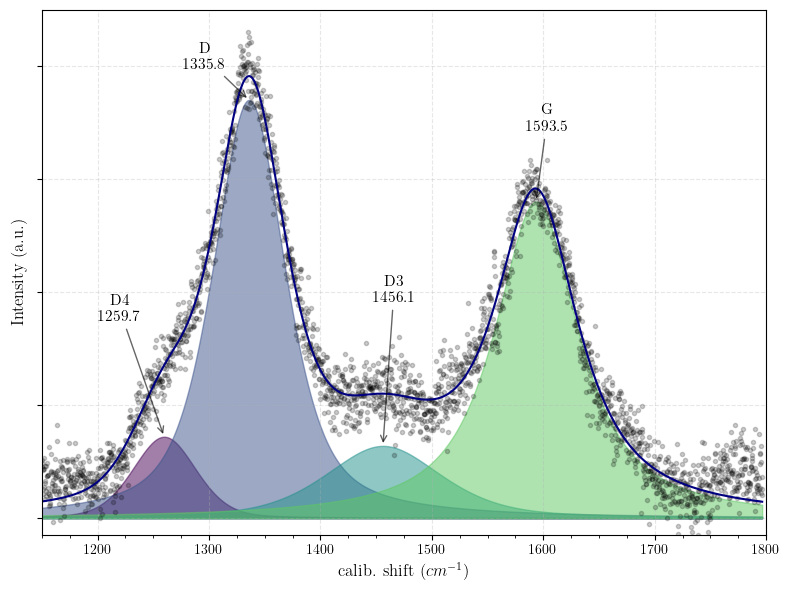

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_800['calib. shift'], data_800['Corrected Intensity'], 'k.', alpha=0.2, label='data_800')
ax.plot(data_800['calib. shift'], data_800['Fit Sum'], color="#000080", label='Fit Sum')

peaks = ['D4', 'D', 'D3', 'G']
colors = plt.get_cmap('viridis')(np.linspace(0, 1, 5))
# colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(peaks)))
for index, peak in enumerate(peaks):
    plt.fill_between(data_800['calib. shift'], data_800[peak], 0, color=colors[index], alpha=0.5, label=peak)


# ----------------------------------------------------------------------------------------------------------------
px1 = 1259.6750784324754
py1 = np.interp(px1, data_800['calib. shift'], data_800['D4'])
plt.annotate(f'D4\n{px1:.1f}', xy=(px1, py1), 
            xytext=(px1 - 40, py1 + 20), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px2 = 1335.8211596176075
py2 = np.interp(px2, data_800['calib. shift'], data_800['D'])
plt.annotate(f'D\n{px2:.1f}', xy=(px2, py2), 
            xytext=(px2 - 40, py2 + 5), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px3 = 1456.0589599560474
py3 = np.interp(px3, data_800['calib. shift'], data_800['D3'])
plt.annotate(f'D3\n{px3:.1f}', xy=(px3, py3), 
            xytext=(px3 + 10, py3 + 25), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px4 = 1593.4980441102357
py4 = np.interp(px4, data_800['calib. shift'], data_800['G'])
plt.annotate(f'G\n{px4:.1f}', xy=(px4, py4), 
            xytext=(px4 + 10, py4 + 12), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')
# ----------------------------------------------------------------------------------------------------------------


ax.set_xlabel(r"calib. shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(1150, 1800)
ax.set_ylim(-3, 90)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.tight_layout()
# plt.savefig(f'../Images/Raman/800_Vigo_fit.pdf', dpi=500)
plt.show()

$L_a = \frac{260}{E_L^4} \cdot \left(\frac{A_D}{A_G}\right)^{-1}$

In [93]:
from scipy.integrate import simpson
q = 1.602176634e-19         # Elementary charge (C)
h = 6.62607015e-34          # Planck constant (J*s)
c0 = 299792458              # speed of light (m/s)
laser = 632.82e-9

mask = (data_800['calib. shift'] >= 1100) & (data_800['calib. shift'] <= 1800)

A_D_800 = simpson(data_800['D'][mask], data_800['calib. shift'][mask])
A_G_800 = simpson(data_800['G'][mask], data_800['calib. shift'][mask])
print(A_D_800, A_G_800)

C_factor = 260/(((h*c0)/(laser*q))**4)
L_800 = C_factor * (A_G_800/A_D_800)
print(C_factor, L_800)

7423.763744972025 6995.256862489158
17.645289133341358 16.626785838141814


In [95]:
file_path = r"C:\Users\lhage\Documents\Seafile\Master\Experiments\Ni-Si\Data\Stückchen\Raman\Raman_Spanien\Exports\900_1100-1800_voigt.txt"

data_900 = pd.read_csv(file_path, sep='\t')

# deduct baseline + O2 line
data_900['Corrected Intensity'] = data_900['Intensity'] - data_900['Baseline'] - data_900['O2']

print(data_900.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2652 entries, 0 to 2651
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Raman shift          2652 non-null   float64
 1   Intensity            2652 non-null   float64
 2   calib. shift         2652 non-null   float64
 3   Baseline             2652 non-null   float64
 4   O2                   2652 non-null   float64
 5   G                    2652 non-null   float64
 6   D                    2652 non-null   float64
 7   D3                   2652 non-null   float64
 8   D4                   2652 non-null   float64
 9   D2                   2652 non-null   float64
 10  Fit Sum              2652 non-null   float64
 11  Corrected Intensity  2652 non-null   float64
dtypes: float64(12)
memory usage: 248.8 KB
None


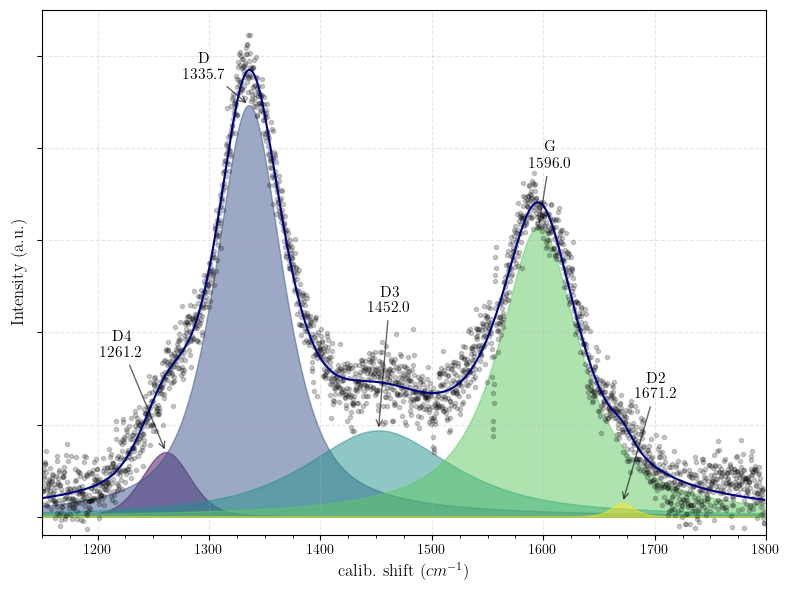

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_900['calib. shift'], data_900['Corrected Intensity'], 'k.', alpha=0.2, label='Data')
ax.plot(data_900['calib. shift'], data_900['Fit Sum'], color="#000080", label='Fit Sum')

peaks = ['D4', 'D', 'D3', 'G', 'D2']
colors = plt.get_cmap('viridis')(np.linspace(0, 1, 5))
# colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(peaks)))
for index, peak in enumerate(peaks):
    plt.fill_between(data_900['calib. shift'], data_900[peak], 0, color=colors[index], alpha=0.5, label=peak)


# ----------------------------------------------------------------------------------------------------------------
px1 = 1261.236795975559
py1 = np.interp(px1, data_900['calib. shift'], data_900['D4'])
plt.annotate(f'D4\n{px1:.1f}', xy=(px1, py1), 
            xytext=(px1 - 40, py1 + 20), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px2 = 1335.7103844373676
py2 = np.interp(px2, data_900['calib. shift'], data_900['D'])
plt.annotate(f'D\n{px2:.1f}', xy=(px2, py2), 
            xytext=(px2 - 40, py2 + 5), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px3 = 1452.0120397821115
py3 = np.interp(px3, data_900['calib. shift'], data_900['D3'])
plt.annotate(f'D3\n{px3:.1f}', xy=(px3, py3), 
            xytext=(px3 + 10, py3 + 25), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px4 = 1595.9874541180113
py4 = np.interp(px4, data_900['calib. shift'], data_900['G'])
plt.annotate(f'G\n{px4:.1f}', xy=(px4, py4), 
            xytext=(px4 + 10, py4 + 12), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')

px5 = 1671.2138504839304
py5 = np.interp(px5, data_900['calib. shift'], data_900['D2'])
plt.annotate(f'D2\n{px5:.1f}', xy=(px5, py5), 
            xytext=(px5 + 30, py5 + 22), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=11, fontweight='bold')
# ----------------------------------------------------------------------------------------------------------------


ax.set_xlabel(r"calib. shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(1150, 1800)
ax.set_ylim(-4, 110)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.tight_layout()
# plt.savefig(f'../Images/Raman/900_Vigo_fit.pdf', dpi=500)
plt.show()

In [96]:
q = 1.602176634e-19         # Elementary charge (C)
h = 6.62607015e-34          # Planck constant (J*s)
c0 = 299792458              # speed of light (m/s)
laser = 632.82e-9

mask = (data_900['calib. shift'] >= 1100) & (data_900['calib. shift'] <= 1800)

A_D_900 = simpson(data_900['D'][mask], data_900['calib. shift'][mask])
A_G_900 = simpson(data_900['G'][mask], data_900['calib. shift'][mask])
print(A_D_900, A_G_900)

C_factor = 260/(((h*c0)/(laser*q))**4)
L_900 = C_factor * (A_G_900/A_D_900)
print(C_factor, L_900)

8712.479638004392 7623.730875801583
17.645289133341358 15.440258246516072
